J24_Projet pratique 2 — Ventes & KPI

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Heure 1 : Comprendre et nettoyer le dataset

In [4]:
#1
df = pd.read_csv("J24_dataset_ventes.csv")
df.info()
df.head()
df.tail()
#2
df.shape
df.dtypes
df["date"] = pd.to_datetime(df["date"],format="mixed",dayfirst=True)
print(df["date"].min())
print(df["date"].max())
#3
Nomb_man = df.isna().sum()
Tot = len(df)
perc = ((Nomb_man) / (Tot)) * 100
perc.round(2)
#4
df[df.duplicated()]
df = df.drop_duplicates()
#5
df["city"].value_counts(dropna=False)
df["channel"].value_counts(dropna=False)
df["category"].value_counts(dropna=False)
df["customer_segment"].value_counts(dropna=False)

df["sale_id"] = df["sale_id"].str.strip().str.title()
df["customer_id"] = df["customer_id"].str.strip().str.title()
df["city"] = df["city"].str.strip().str.lower()
df["region"] = df["region"].str.strip().str.title()
df["channel"] = df["channel"].str.strip().str.lower()
df["category"] = df["category"].str.strip().str.lower()
df["product"] = df["product"].str.strip().str.title()
#6
corrections_categorie = {
    "Electronic": "Electronique",
    "Burau": "Bureau",  
    "Maisson": "Maison",  
    }

df["category"] = df["category"].replace(corrections_categorie)

corrections_canaux = {
    "Comercial": "Commercial",
    "Commercialle ": "Commercial",  
    "Commerciale": "Commercial",
     "EnLigne": "En Ligne",
         "En ligne": "En Ligne",  
         "Magassin": "Magasin", 
         "Magasine" : "Magasin" 
    }
df["channel"] = df["channel"].replace(corrections_canaux)

corrections_ville = {
    "Casa": "Casablanca",
    "casa": "Casablanca",  
    "Rbat": "Rabat",
     "Raba": "Rabat",
      "Tangier": "Tanger",  
     "Marrakach": "Marrakech", 
    "Marakech" : "Marrakech",
    "Marrakesh" : "Marrakech",
    "Fès" : "Fes"
    }
df["city"] = df["city"].replace(corrections_ville)

df["customer_segment"] = (
    df["customer_segment"]
    .str.strip()
    .str.lower()
    .replace({
        "particulier": "Particulier",
        "pme": "PME",
        "grand compte": "Grand compte"
    })
)
#7
df["date"] = pd.to_datetime(df["date"], format="mixed")
#8
df[
    [
        "quantity",
        "discount_pct",
        "unit_price_mad",
        "unit_cost_mad"
    ]].describe()
""" sns.scatterplot(data = df, x = "quantity",y="unit_price_mad", hue = "product")
sns.scatterplot(data = df, x = "quantity",y="unit_cost_mad", hue = "product")
sns.scatterplot(data = df, x = "quantity",y="discount_pct", hue = "product") """
#9
df["customer_segment"] = df["customer_segment"].fillna("Inconnu") #Variable categorielle
df["city"] = df["city"].fillna(df["city"].mode()[0]) #Variable categorielle
df["discount_pct"] = df["discount_pct"].fillna(df["discount_pct"].median()) #Variable numerique
df["salesperson"] = df["salesperson"].fillna("Inconnu") #Variable categorielle
#10
df["revenue_mad"] = df["quantity"] * df["unit_price_mad"] * (1-(df["discount_pct"] / 100))
df["total_cost_mad"] = df["quantity"] * df["unit_cost_mad"]
df["profit_mad"] = df["revenue_mad"] - df["total_cost_mad"]
df["margin_pct"] = (df["profit_mad"] / df["revenue_mad"]) * 100

df.info()
df.dtypes
df.describe()
df.isna().sum().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           906 non-null    str    
 1   date              906 non-null    str    
 2   customer_id       906 non-null    str    
 3   customer_segment  898 non-null    str    
 4   city              896 non-null    str    
 5   region            906 non-null    str    
 6   channel           906 non-null    str    
 7   category          906 non-null    str    
 8   product           906 non-null    str    
 9   quantity          906 non-null    int64  
 10  unit_price_mad    906 non-null    float64
 11  unit_cost_mad     906 non-null    float64
 12  discount_pct      894 non-null    float64
 13  salesperson       900 non-null    str    
 14  payment_method    906 non-null    str    
dtypes: float64(3), int64(1), str(11)
memory usage: 106.3 KB
2026-01-01 00:00:00
2026-12-08 00:00:00
<class

np.int64(0)

Heure 2 :  GroupBy, Pivot Table, KPI et segmentation

Nombre : 5
Part : 0.56 %
count     5.000000
mean     43.000000
std      13.038405
min      30.000000
25%      30.000000
50%      45.000000
75%      50.000000
max      60.000000
Name: discount_pct, dtype: float64


,effectif_transactions,quantite,chiffr_aff,profit_sum,marge_moyen,panier_moyen
region,,,,,,
Casablanca-Settat,326,1025,2205591.22,671259.23,36.09,6765.62
Fes-Meknes,110,303,663228.60,175853.60,35.83,6029.35
Marrakech-Safi,139,485,1220279.04,343042.10,34.78,8778.99
Rabat-Sale-Kenitra,205,667,1743921.83,458550.38,35.60,8506.94
Tanger-Tetouan-Al Hoceima,120,404,1125942.96,298968.65,33.75,9382.86


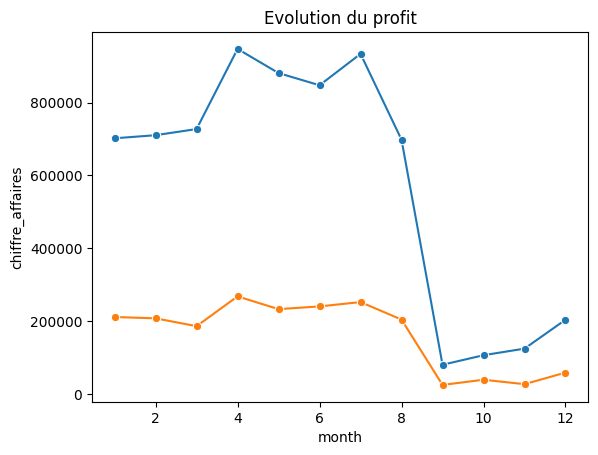

In [16]:
#1
CA_Total = df["revenue_mad"].sum()
CA_Total.round(2)
Profit_tot = df["profit_mad"].sum()
Profit_tot.round(2)
quantite_tot_ven = df["quantity"].sum()
quantite_tot_ven.round(2)
Valeur_moy_tr = (df["revenue_mad"]).mean().round(2)
Valeur_moy_tr
#2
top_5_produits = (
    df.groupby("product")
    .agg(chiffre_affaires=("revenue_mad", "sum"))
    .sort_values(by="chiffre_affaires", ascending=False)
    .head(5))
top_5_produits
#3
Mon_Tab = df.groupby("category").agg(nombre_transactions=("sale_id","count"),
quantite_vendue = ("quantity","sum"),
chiffr_aff = ("revenue_mad","sum"),    
profit=("profit_mad", "sum"),    
marge_moy = ("margin_pct","mean")).round(2)
#4
df.groupby("region").agg(chiffr_aff = ("revenue_mad","sum"),    
profit_sum = ("profit_mad","sum"),
transactions_moy=("revenue_mad", "mean")
).round(2)
#5
df.groupby("channel").agg(chiffr_aff = ("revenue_mad","sum"),    
profit_sum = ("profit_mad","sum"),
marge_moy = ("margin_pct","mean"),
nombre_transactions=("sale_id","count")
).round(2)
#6
df["month"] = df["date"].dt.month
evolution_mensuelle = df.groupby("month").agg(
    chiffre_affaires=("revenue_mad", "sum"),
    profit=("profit_mad", "sum")).round(2)

evolution_mensuelle
sns.lineplot(data=evolution_mensuelle, x= "month" , y = "chiffre_affaires", marker = "o")
plt.title("Evolution du CA")

sns.lineplot(data=evolution_mensuelle, x= "month" , y = "profit", marker = "o")
plt.title("Evolution du profit")
#7
pd.pivot_table(df,values="revenue_mad",index = "category", columns = "channel",aggfunc="sum",)
#8
df.groupby(["customer_segment"]).agg(effectif_transactions=("sale_id","count"),
chiffr_aff = ("revenue_mad","sum"),    
panier_moyen = ("revenue_mad","mean"),
profit=("profit_mad", "sum"),
marge_moy = ("margin_pct","mean")).round(2)
#9
sales_by_person = (
    df.groupby("salesperson")
    .agg(
        nb_transactions=("sale_id", "count"),
        total_ca=("revenue_mad", "sum"),
        total_profit=("profit_mad", "sum"),).reset_index())
plus_20 = sales_by_person[sales_by_person["nb_transactions"] >= 20]
trois_meill_CA = plus_20.sort_values(by = "total_ca",ascending=False).head(3)
trois_meill_profit = plus_20.sort_values(by = "total_profit",ascending=False).head(3)
trois_meill_CA
trois_meill_profit
#10
transactions_perte = df[df["profit_mad"] < 0]
nombre_pertes = len(transactions_perte)
part_pertes = (nombre_pertes / len(df)) * 100
remises_pertes = transactions_perte["discount_pct"].describe()

print("Nombre :", nombre_pertes)
print("Part :", round(part_pertes, 2), "%")
print(remises_pertes)
#11
plus_max_CA = Mon_Tab.sort_values(by = "chiffr_aff" , ascending= False).head(1)
plus_min_marg = Mon_Tab.sort_values(by = "marge_moy" , ascending= False).tail(1)
plus_max_CA
plus_min_marg
#12
region_tab = df.groupby(["region"]).agg(effectif_transactions=("sale_id","count"),
quantite = ("quantity","sum"),                                        
chiffr_aff = ("revenue_mad","sum"),
profit_sum= ("profit_mad","sum"), 
marge_moyen = ("margin_pct","mean"),   
panier_moyen =("revenue_mad", "mean"),
).round(2)
region_tab

Heure 3  : Visualisations et interpretation

In [ ]:
#1
evolution_mensuelle = df.groupby("month").agg(chiffre_affaires=("revenue_mad", "sum"),
                                              profit=("profit_mad", "sum")).round(2)
sns.lineplot(data=evolution_mensuelle, x= "month" , y = "chiffre_affaires", marker = "o")
plt.title("Evolution du CA")
#2
Mon_Tab = df.groupby("category").agg(nombre_transactions=("sale_id","count"),
quantite_vendue = ("quantity","sum"),
chiffr_aff = ("revenue_mad","sum"),    
profit=("profit_mad", "sum"),    
marge_moy = ("margin_pct","mean")).round(2)
sns.scatterplot(data=Mon_Tab, x= "profit" , y = "chiffr_aff", marker = "o")
plt.title("Relation entre CA et le profit")
#3
Mon_heatm = pd.pivot_table(df,values="revenue_mad",index = "category", columns = "channel",aggfunc="sum",)
sns.heatmap(Mon_heatm , annot = True, fmt=".0f")
#4
top_5_produits = (df.groupby("product").agg(chiffre_affaires=("revenue_mad", "sum"))
    .sort_values(by="chiffre_affaires", ascending=False)
    .head(5))
top_5_produits = top_5_produits.reset_index()
sns.barplot(data=top_5_produits, y="product",x="chiffre_affaires")
plt.xticks(rotation = 45)
plt.title("Graphique horizontal des 5 produits qui generent le plus de CA")
#5
sns.scatterplot(data = df, x = "discount_pct", y ="margin_pct", marker = "o" )
"""Le scatterplot montre une tendance négative entre la remise et la marge
Donc il existe une association négative modérée :
plus la remise augmente, plus la marge tend à diminuer."""
#6
sns.boxplot(data = df, x="customer_segment", y = "revenue_mad")
#7
"""1. La catégorie Electronique génère environ 4,73 M MAD de CA,
   soit très largement la première catégorie.
2. Laptop Pro 14 est le produit n°1 avec environ
   2,41 M MAD de chiffre d'affaires.
3. Casablanca-Settat arrive en tête avec environ
   2,21 M MAD de CA et 671 000 MAD de profit.
4. Mai est le meilleur mois avec environ 1,02 M MAD de CA,
   contre environ 719 000 MAD en février.
5. Les transactions en perte représentent seulement environ 0,56 %
   des ventes, mais leur remise moyenne est d'environ 43 %,
   contre 9,31 % sur l'ensemble du dataset."""
#8
"""Action 1 — surveiller les remises élevées
Les transactions en perte ont une remise moyenne d'environ 43 %, contre 9,31 % globalement. 
Mettre en place une validation commerciale supplémentaire au-delà d'un certain niveau de 
remise pourrait limiter les ventes non rentables.

Attention : ce n'est pas « interdire les remises », mais contrôler les remises importantes.

Action 2 — travailler la rentabilité de l'Electronique 
Puisque l’Electronique génère le plus gros CA mais présente la marge moyenne la plus faible,
 analyser les coûts, prix et remises de cette catégorie pourrait améliorer fortement le profit global."""

,sale_id,date,customer_id,customer_segment,city,region,channel,category,product,quantity,unit_price_mad,unit_cost_mad,discount_pct,salesperson,revenue_mad,total_cost_mad,profit_mad,margin_pct,month
payment_method,,,,,,,,,,,,,,,,,,,
Carte,216,216,216,216,216,216,216,216,216,216,216,216,216,216,216,216,216,216,216
Especes,237,237,237,237,237,237,237,237,237,237,237,237,237,237,237,237,237,237,237
Paiement mobile,230,230,230,230,230,230,230,230,230,230,230,230,230,230,230,230,230,230,230
Virement,217,217,217,217,217,217,217,217,217,217,217,217,217,217,217,217,217,217,217
